Iteration No: 1 started. Evaluating function at random point.
Iteration No: 1 ended. Evaluation done at random point.
Time taken: 7.3917
Function value obtained: 0.0014
Current minimum: 0.0014
Iteration No: 2 started. Evaluating function at random point.
Iteration No: 2 ended. Evaluation done at random point.
Time taken: 8.5825
Function value obtained: 0.0014
Current minimum: 0.0014
Iteration No: 3 started. Evaluating function at random point.
Iteration No: 3 ended. Evaluation done at random point.
Time taken: 17.8790
Function value obtained: 0.0018
Current minimum: 0.0014
Iteration No: 4 started. Evaluating function at random point.
Iteration No: 4 ended. Evaluation done at random point.
Time taken: 8.7911
Function value obtained: 0.0014
Current minimum: 0.0014
Iteration No: 5 started. Evaluating function at random point.
Iteration No: 5 ended. Evaluation done at random point.
Time taken: 6.1449
Function value obtained: 0.0016
Current minimum: 0.0014
Iteration No: 6 started. Evaluatin

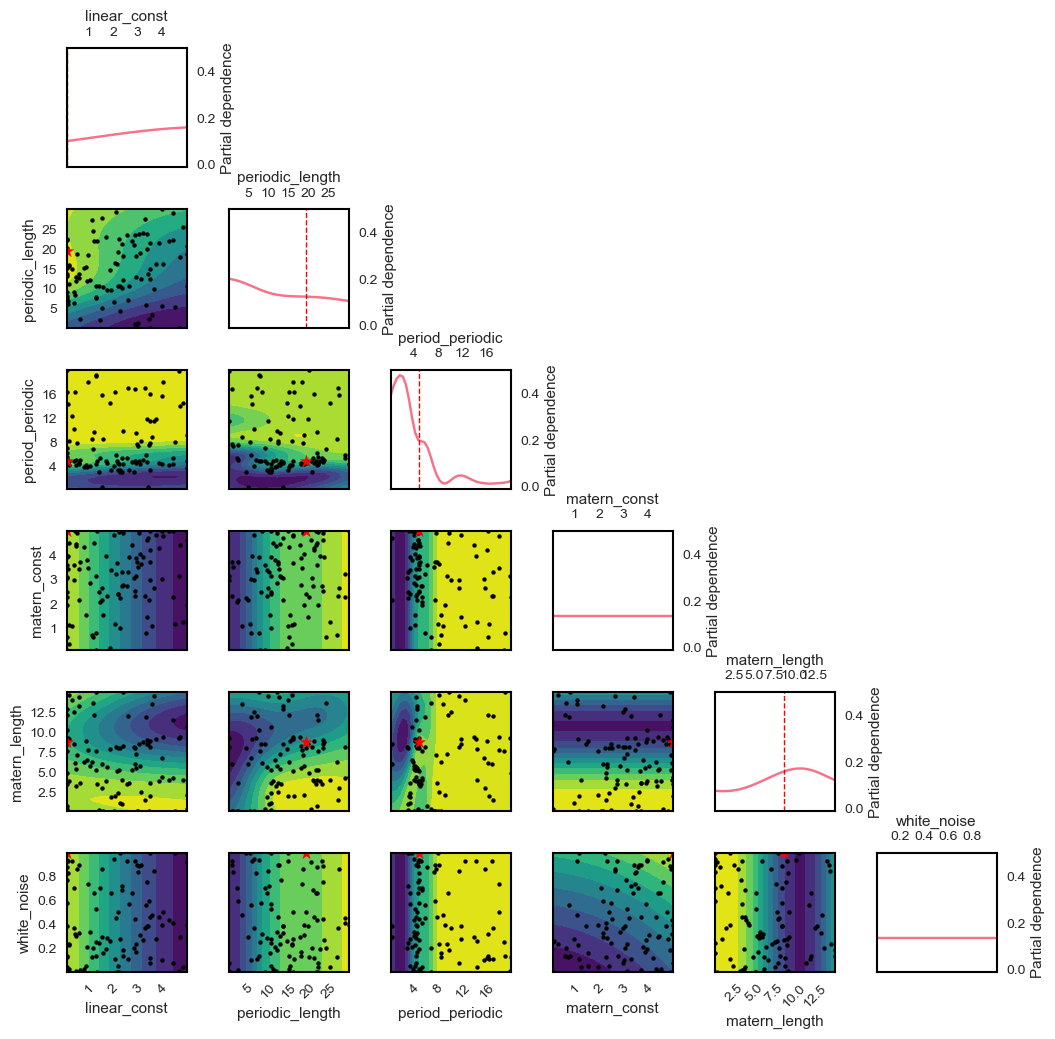

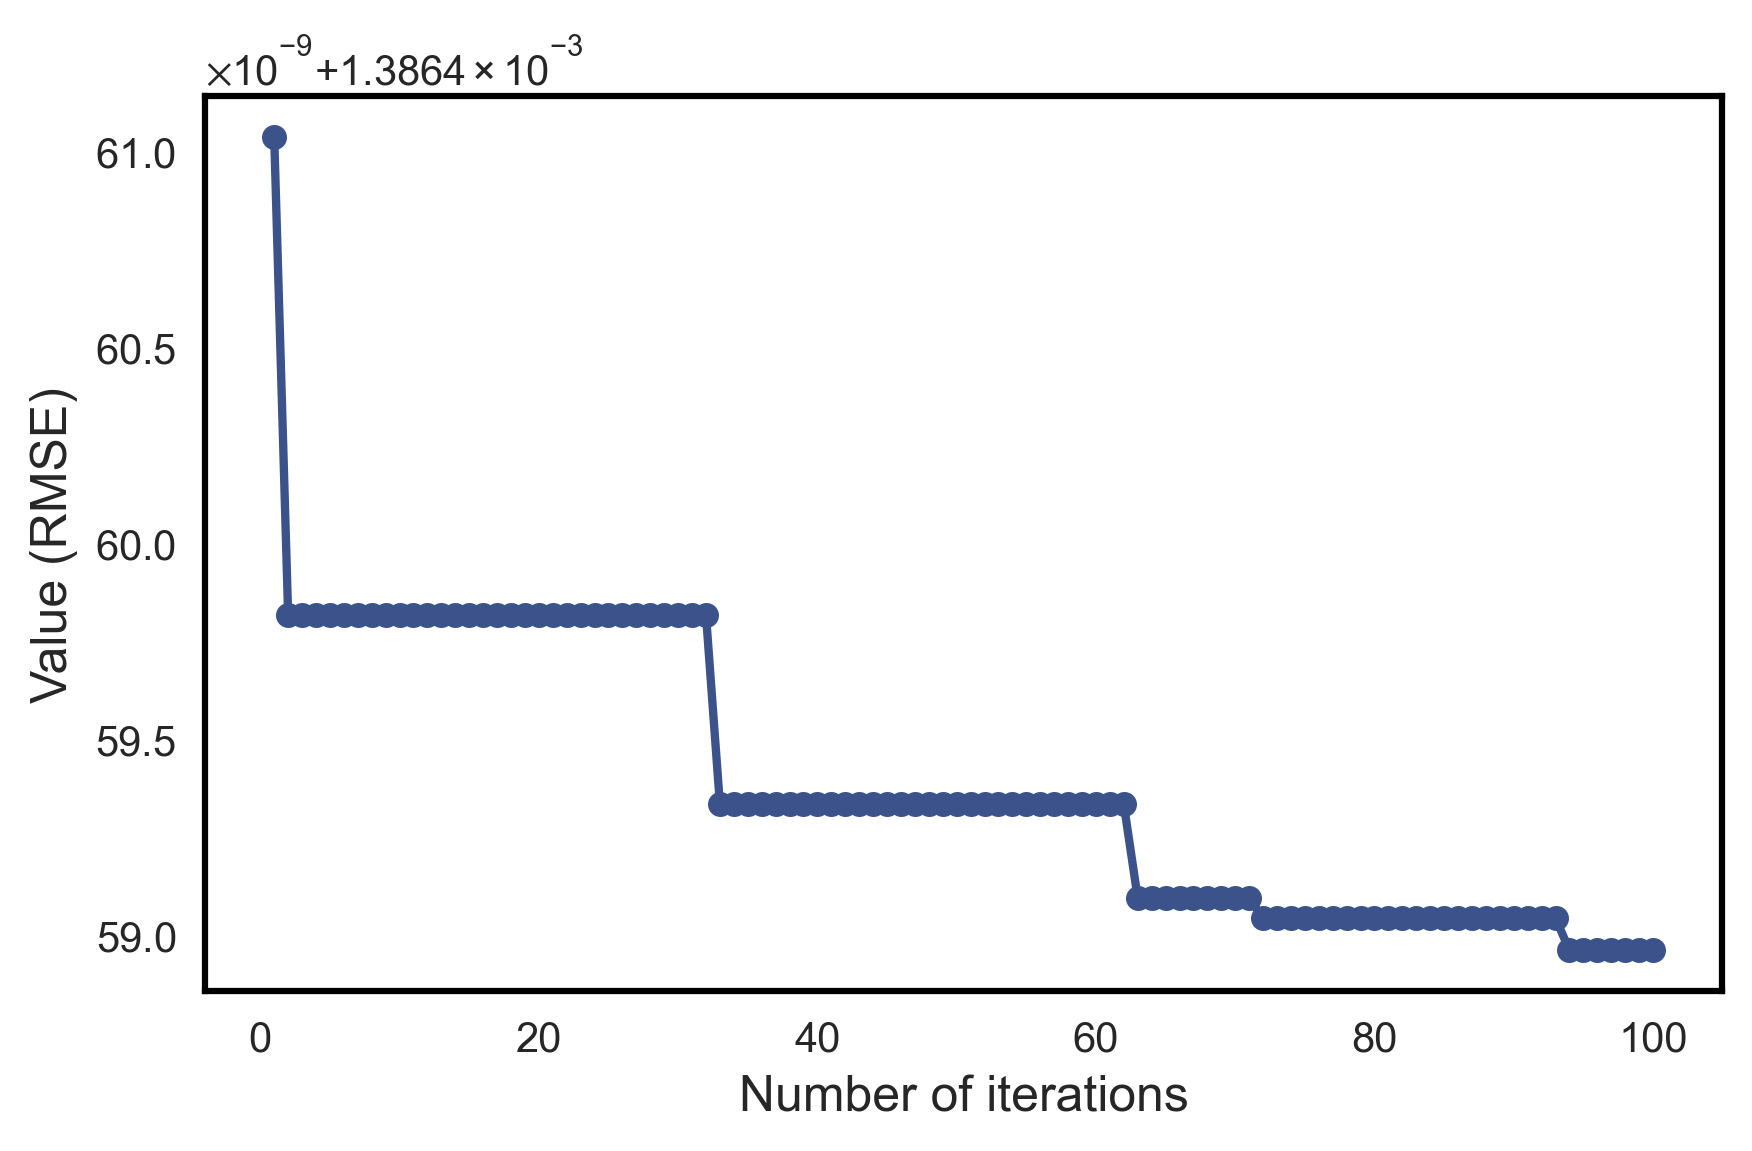


训练最终模型...


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, DotProduct, ExpSineSquared, ConstantKernel
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt
from skopt import gp_minimize
from skopt.space import Real
from skopt.plots import plot_convergence, plot_objective
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

import seaborn as sns
plt.rcParams['font.serif'] = ['Times New Roman'] 
plt.rcParams['axes.unicode_minus'] = False 
plt.style.use('seaborn-v0_8')

plt.rcParams.update({
    'font.serif': 'Times New Roman', 
    'axes.unicode_minus': False,
    'font.size': 12,
    'axes.facecolor': 'white',
    'figure.facecolor': 'white',
    'axes.linewidth': 1.5,
    'axes.edgecolor': 'black',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'mathtext.fontset': 'stix'  
})
sns.set_palette("husl")
seed = 42
np.random.seed(seed)

data = pd.read_excel(r'C:\Users\h\Desktop\小论文\BDI1000\CEEMDAN.xlsx', sheet_name='Sheet1')
low_freq = data.iloc[:, 2].values.reshape(-1, 1)
n_steps = 5
def create_dataset(data, n_steps):
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data[i:i+n_steps].flatten())
        y.append(data[i + n_steps])
    return np.array(X), np.array(y)
train_size_original = int(len(low_freq) * 0.7)
train_data = low_freq[:train_size_original]
test_data = low_freq[train_size_original:]
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)
X_train, y_train = create_dataset(train_scaled, n_steps)
test_extended = np.concatenate([train_scaled[-n_steps:], test_scaled])
X_test, y_test = create_dataset(test_extended, n_steps)
dimensions = [
    Real(name='linear_const', low=0.1, high=5),
    Real(name='periodic_length', low=0.1, high=30),
    Real(name='period_periodic', low=0.1, high=20),
    Real(name='matern_const', low=0.1, high=5),
    Real(name='matern_length', low=0.1, high=15),
    Real(name='white_noise', low=1e-4, high=1)
]
def objective(params):
    const_linear, ls_periodic, period_periodic, const_matern, ls_matern, noise = params
    kernel = (ConstantKernel(const_linear) * DotProduct()) * \
             ExpSineSquared(length_scale=ls_periodic, periodicity=period_periodic) + \
             (ConstantKernel(const_matern) * Matern(length_scale=ls_matern, nu=2.5)) + \
             WhiteKernel(noise_level=noise)
    tscv = TimeSeriesSplit(n_splits=3)
    splits = list(tscv.split(X_train))
    rmse_scores = []
    for train_idx, val_idx in splits:
        gpr = GaussianProcessRegressor(
            kernel=kernel,
            alpha=0,
            n_restarts_optimizer=3,
            random_state=seed
        )
        gpr.fit(X_train[train_idx], y_train[train_idx])
        y_pred = gpr.predict(X_train[val_idx])
        rmse = np.sqrt(mean_squared_error(y_train[val_idx], y_pred))
        rmse_scores.append(rmse)
    return np.mean(rmse_scores)
result = gp_minimize(
    objective,
    dimensions,
    n_calls=100,
    n_random_starts=20,
    random_state=seed,
    verbose=True
)
best_params = result.x
best_const_linear, best_ls_periodic, best_period_periodic, best_const_matern, best_ls_matern, best_noise = best_params
print(f"最优参数: Linear(const={best_const_linear:.3f}) * Periodic(ls={best_ls_periodic:.3f}, period={best_period_periodic:.3f}) | "
      f"Matern(const={best_const_matern:.3f}, ls={best_ls_matern:.3f}) | Noise={best_noise:.3f}")
ax_array = plot_objective(result, size=2, minimum='expected_minimum')
plt.savefig('C:/Users/h/Desktop/小论文/BDI1000/Fig11.pdf', format='pdf', dpi=300)

fig, ax = plt.subplots(figsize=(6, 4),dpi=300)
plot_convergence(result, ax=ax)
ax.set_title(' ', fontsize=14)
ax.set_xlabel('Number of iterations', fontsize=12)
ax.set_ylabel('Value (RMSE)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)
ax.grid(alpha=0.5)
plt.tight_layout()
plt.savefig('C:/Users/h/Desktop/小论文/BDI1000/Fig10.pdf', format='pdf', dpi=300)
plt.show()

best_kernel = (ConstantKernel(best_const_linear) * DotProduct()) * \
              ExpSineSquared(length_scale=best_ls_periodic, periodicity=best_period_periodic) + \
              (ConstantKernel(best_const_matern) * Matern(length_scale=best_ls_matern, nu=2.5)) + \
              WhiteKernel(noise_level=best_noise)
gpr = GaussianProcessRegressor(
    kernel=best_kernel,
    alpha=0,
    n_restarts_optimizer=10,
    random_state=seed
)
print("\n训练最终模型...")
gpr.fit(X_train, y_train)
def predict_and_inverse(model, X):
    y_pred, y_std = model.predict(X, return_std=True)
    y_pred = scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()
    return y_pred, y_std
train_pred, train_std = predict_and_inverse(gpr, X_train)
test_pred, test_std = predict_and_inverse(gpr, X_test)

y_train_inv = scaler.inverse_transform(y_train.reshape(-1, 1)).flatten()
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

def safe_mape(y_true, y_pred):
    epsilon = 1e-10
    return np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + epsilon)) * 100)
def directional_accuracy(y_true, y_pred):
    true_direction = np.sign(np.diff(y_true))
    pred_direction = np.sign(np.diff(y_pred))
    correct = (true_direction == pred_direction)
    dr = np.mean(correct) * 100
    return dr

metrics = [
    ('RMSE', lambda y_t, y_p: np.sqrt(mean_squared_error(y_t, y_p))),
    ('MAE', mean_absolute_error),
    ('MAPE', safe_mape),
    ('R²', r2_score),
    ('DR', directional_accuracy)
]

results = {}
for name, metric in metrics:
    train_value = metric(y_train_inv, train_pred)
    test_value = metric(y_test_inv, test_pred)
    results[f'Train {name}'] = train_value
    results[f'Test {name}'] = test_value

results_df = pd.DataFrame([results])
print("\n模型性能评估:")
print(results_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4),dpi=300)
full_pred = np.concatenate([train_pred, test_pred])
full_actual = np.concatenate([y_train_inv, y_test_inv])

time_index = np.arange(len(full_actual))
ax.plot(time_index, full_actual, color='black', lw=1.2, label='Actual values', alpha=0.8)
ax.plot(time_index[:len(train_pred)], train_pred, 
         color='tab:blue', marker='o', markersize=2, lw=1.0, label='Training set predictions')
ax.plot(time_index[len(train_pred):], test_pred, 
         color='tab:red', marker='o', markersize=2, lw=1.0, label='Test set predictions')
ax.fill_between(time_index[len(train_pred):],
                 test_pred - 1.96*test_std*scaler.scale_[0],
                 test_pred + 1.96*test_std*scaler.scale_[0],
                 color='#ff7f0e', alpha=0.2, label='95% confidence interval')
ax.axvline(x=len(train_pred), color='gray', ls='--', lw=1.2)
ax.set_xlabel('Time step', fontsize=12)
ax.set_ylabel('Value', fontsize=12)
ax.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='black', fontsize=11)
ax.grid(alpha=0.5)
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)
plt.tight_layout()
plt.savefig(r'C:\Users\h\Desktop\小论文\BDI1000\Fig12.pdf', format='pdf', dpi=300)
plt.show()

output_path = r'C:\Users\h\Desktop\小论文\BDI1000\BO-滤波-GPR\CEEMDAN低频预测结果.xlsx'
with pd.ExcelWriter(output_path) as writer:
    results_df.to_excel(writer, sheet_name='模型评估', index=False)
    pd.DataFrame({
        '实际值': full_actual,
        '预测值': full_pred,
        '预测标准差': np.concatenate([train_std, test_std]) * scaler.scale_[0]
    }).to_excel(writer, sheet_name='完整预测', index=False)
    pd.DataFrame({
        '训练集预测': np.concatenate([train_pred, np.full(len(test_pred), np.nan)]),
        '测试集预测': np.concatenate([np.full(len(train_pred), np.nan), test_pred])
    }).to_excel(writer, sheet_name='分组预测', index=False)

print("\n结果已保存至:", output_path)